Übersichtliches Diagramm

In diesem du siehst, welche Daten in welches Modell fließen und welche Outputs die Modelle haben.

In [2]:
from graphviz import Digraph

# Diagramm initialisieren
dot = Digraph("ML_Pipeline", format="png")
dot.attr(rankdir="LR", bgcolor="white")
dot.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="10")

# Farben / Styles
COLOR_DATA = "#E3F2FD"      # hellblau für Daten
COLOR_MODEL = "#E8F5E9"     # hellgrün für Modelle
COLOR_OUTPUT = "#FFF3E0"    # hellorange für Outputs

# ==============
# Datenknoten (mit Subscripts)
# ==============

dot.node("D_Load", "<Lastprognose<br/>L<sub>fc</sub>(t)>", fillcolor=COLOR_DATA)
dot.node("D_Wind", "<Windprognose<br/>W<sub>fc</sub>(t)>", fillcolor=COLOR_DATA)
dot.node("D_PV", "<PV-Prognose<br/>PV<sub>fc</sub>(t)>", fillcolor=COLOR_DATA)
dot.node("D_ResLoad", "<Residuallast<br/>L<sub>res</sub>(t)>", fillcolor=COLOR_DATA)
dot.node("D_Fuel", "<Fuel-/CO₂-Preise<br/>p<sub>gas</sub>(d), p<sub>CO₂</sub>(d)>", fillcolor=COLOR_DATA)
dot.node("D_Calendar", "<Kalender-Features<br/>Wochentag, Stunde,<br/>Saison, Feiertage>", fillcolor=COLOR_DATA)

# Day-Ahead spezifische Daten
dot.node("D_DA_Hist", "<DA-Preise Historie<br/>P<sub>DA</sub>(t), Lags>", fillcolor=COLOR_DATA)
dot.node("D_Neighbors", "<Nachbarzonenpreise<br/>P<sub>DA</sub><sup>FR</sup>, P<sub>DA</sub><sup>NL</sup>,<br/>P<sub>DA</sub><sup>AT</sup>, P<sub>DA</sub><sup>DK</sup>>", fillcolor=COLOR_DATA)
dot.node("D_CB_Flows", "<Cross-Border-Flows<br/>X<sub>net</sub>(t)>", fillcolor=COLOR_DATA)

# Regelmarkt spezifische Daten
dot.node("D_Bal_Energy", "<Aktivierte aFRR/mFRR-Energie<br/>E<sub>aFRR_up</sub>(t), E<sub>mFRR_up</sub>(t)>", fillcolor=COLOR_DATA)
dot.node("D_Bal_Cap", "<Beschaffte Kapazitäten<br/>Q<sub>aFRR_up</sub>(t), Q<sub>mFRR_up</sub>(t)>", fillcolor=COLOR_DATA)
dot.node("D_reBAP", "<reBAP / Imbalance-Preis<br/>P<sub>reBAP</sub>(t)>", fillcolor=COLOR_DATA)
dot.node("D_Saldo", "<Systemsaldodaten<br/>S(t)>", fillcolor=COLOR_DATA)
dot.node("D_ID", "<Intraday-Preise (optional)<br/>P<sub>ID</sub>(t)>", fillcolor=COLOR_DATA)

# ==============
# Modellknoten
# ==============

# Modell 1: Day-Ahead Preis
dot.node(
    "M_DA",
    "<Modell 1: Day-Ahead-Preis<br/>Output: P<sub>DA</sub>(t) → p<sub>ref</sub>, P̄<sub>DA</sub>>",
    shape="box",
    fillcolor=COLOR_MODEL,
    fontsize="11",
    penwidth="1.5"
)

# Modell 2: Kapazitätspreis
dot.node(
    "M_CAP",
    "<Modell 2: Balancing Kapazitätspreis<br/>Output: π<sub>cap,w</sub>>",
    shape="box",
    fillcolor=COLOR_MODEL,
    fontsize="11",
    penwidth="1.5"
)

# Modell 3: Aktivierung
dot.node(
    "M_ACT",
    "<Modell 3: Balancing Aktivierung<br/>Outputs: π<sub>act,w</sub>, α<sub>w</sub>>",
    shape="box",
    fillcolor=COLOR_MODEL,
    fontsize="11",
    penwidth="1.5"
)

# ==============
# Output-Knoten (für Profit-Berechnung)
# ==============

dot.node("O_pref", "<Einstandspreis<br/>p<sub>ref</sub>>", fillcolor=COLOR_OUTPUT)
dot.node("O_Pbar_DA", "<Durchschnittlicher<br/>DA-Preis P̄<sub>DA</sub>>", fillcolor=COLOR_OUTPUT)
dot.node("O_pi_cap", "<Kapazitätspreis<br/>π<sub>cap,w</sub>>", fillcolor=COLOR_OUTPUT)
dot.node("O_pi_act", "<Aktivierungspreis<br/>π<sub>act,w</sub>>", fillcolor=COLOR_OUTPUT)
dot.node("O_alpha", "<Aktivierungsgrad<br/>α<sub>w</sub>>", fillcolor=COLOR_OUTPUT)

dot.node(
    "O_Profit_DA",
    "<Profit Day-Ahead<br/>Π_DA = E0 · (P̄<sub>DA</sub> - p<sub>ref</sub> - c_var)>",
    fillcolor="#FFE0B2",
    fontsize="10"
)

dot.node(
    "O_Profit_BAL",
    "<Profit Regelmarkt<br/>Π_bal = Q<sub>cap</sub>·T·[π<sub>cap,w</sub> + α<sub>w</sub>·(π<sub>act,w</sub> - p<sub>ref</sub> - c_var)]>",
    fillcolor="#FFE0B2",
    fontsize="10"
)

# ==============
# Kanten: Daten → Modelle
# ==============

# Modell 1 (Day-Ahead)
for src in ["D_Load", "D_Wind", "D_PV", "D_ResLoad", "D_Fuel", "D_Calendar",
            "D_DA_Hist", "D_Neighbors", "D_CB_Flows"]:
    dot.edge(src, "M_DA", color="#90CAF9")

# Modell 2 (Kapazitätspreis, wöchentliche Aggregation dieser Daten)
for src in ["D_ResLoad", "D_DA_Hist", "D_Fuel", "D_Bal_Cap", "D_Saldo", "D_Calendar"]:
    dot.edge(src, "M_CAP", color="#A5D6A7")

# Modell 3 (Aktivierung, wöchentliche Aggregation dieser Daten)
for src in ["D_Bal_Energy", "D_Bal_Cap", "D_reBAP", "D_Saldo",
            "D_DA_Hist", "D_ID", "D_ResLoad", "D_Calendar"]:
    dot.edge(src, "M_ACT", color="#FFCC80")

# ==============
# Kanten: Modelle → Outputs
# ==============

# Modell 1 Outputs
dot.edge("M_DA", "O_pref", label="aus Vorwochen-Mittelwert", fontsize="9")
dot.edge("M_DA", "O_Pbar_DA", label="Wochenmittel", fontsize="9")

# Modell 2 Output
dot.edge("M_CAP", "O_pi_cap")

# Modell 3 Outputs
dot.edge("M_ACT", "O_pi_act")
dot.edge("M_ACT", "O_alpha")

# Kanten zu Profitberechnungen
dot.edge("O_pref", "O_Profit_DA")
dot.edge("O_Pbar_DA", "O_Profit_DA")
dot.edge("O_pref", "O_Profit_BAL")
dot.edge("O_pi_cap", "O_Profit_BAL")
dot.edge("O_pi_act", "O_Profit_BAL")
dot.edge("O_alpha", "O_Profit_BAL")

# Diagramm ausgeben (z.B. in Jupyter Notebook oder als Datei)
dot.render("ml_pipeline_profit", cleanup=True)
print(dot.source)


digraph ML_Pipeline {
	bgcolor=white rankdir=LR
	node [fontname=Helvetica fontsize=10 shape=box style="rounded,filled"]
	D_Load [label=<Lastprognose<br/>L<sub>fc</sub>(t)> fillcolor="#E3F2FD"]
	D_Wind [label=<Windprognose<br/>W<sub>fc</sub>(t)> fillcolor="#E3F2FD"]
	D_PV [label=<PV-Prognose<br/>PV<sub>fc</sub>(t)> fillcolor="#E3F2FD"]
	D_ResLoad [label=<Residuallast<br/>L<sub>res</sub>(t)> fillcolor="#E3F2FD"]
	D_Fuel [label=<Fuel-/CO₂-Preise<br/>p<sub>gas</sub>(d), p<sub>CO₂</sub>(d)> fillcolor="#E3F2FD"]
	D_Calendar [label=<Kalender-Features<br/>Wochentag, Stunde,<br/>Saison, Feiertage> fillcolor="#E3F2FD"]
	D_DA_Hist [label=<DA-Preise Historie<br/>P<sub>DA</sub>(t), Lags> fillcolor="#E3F2FD"]
	D_Neighbors [label=<Nachbarzonenpreise<br/>P<sub>DA</sub><sup>FR</sup>, P<sub>DA</sub><sup>NL</sup>,<br/>P<sub>DA</sub><sup>AT</sup>, P<sub>DA</sub><sup>DK</sup>> fillcolor="#E3F2FD"]
	D_CB_Flows [label=<Cross-Border-Flows<br/>X<sub>net</sub>(t)> fillcolor="#E3F2FD"]
	D_Bal_Energy [label=<Akti

### Interaktives Sankey-Diagramm
Zeigt die Kette Daten → Modelle → Outputs in einer kompakten, modernen Grafik. Läuft in Jupyter/VS Code; ggf. `pip install plotly`.


In [3]:
import plotly.graph_objects as go

# Daten-, Modell- und Output-Knoten definieren
# (key = interne ID, label = Anzeige, detail = Beschreibung, color = Knotenfarbe)
data_nodes = [
    {"key": "load", "label": "Lastprognose L<sub>fc</sub>(t)", "detail": "Stündliche Nachfrageprognose", "color": "#60a5fa"},
    {"key": "wind", "label": "Windprognose W<sub>fc</sub>(t)", "detail": "Einspeisung Wind", "color": "#60a5fa"},
    {"key": "pv", "label": "PV-Prognose PV<sub>fc</sub>(t)", "detail": "Einspeisung PV", "color": "#60a5fa"},
    {"key": "resload", "label": "Residuallast L<sub>res</sub>(t)", "detail": "Last abzügl. EE", "color": "#60a5fa"},
    {"key": "fuel", "label": "Fuel-/CO₂-Preise", "detail": "p<sub>gas</sub>(d), p<sub>CO₂</sub>(d)", "color": "#60a5fa"},
    {"key": "calendar", "label": "Kalender-Features", "detail": "Wochentag, Stunde, Saison, Feiertage", "color": "#60a5fa"},
    {"key": "da_hist", "label": "DA-Preise Historie", "detail": "P<sub>DA</sub>(t), Lags", "color": "#60a5fa"},
    {"key": "neighbors", "label": "Nachbarzonenpreise", "detail": "FR / NL / AT / DK", "color": "#60a5fa"},
    {"key": "cb_flows", "label": "Cross-Border-Flows", "detail": "X<sub>net</sub>(t)", "color": "#60a5fa"},
    {"key": "bal_energy", "label": "Aktivierte aFRR/mFRR", "detail": "E<sub>aFRR_up</sub>(t), E<sub>mFRR_up</sub>(t)", "color": "#60a5fa"},
    {"key": "bal_cap", "label": "Beschaffte Kapazitäten", "detail": "Q<sub>aFRR_up</sub>(t), Q<sub>mFRR_up</sub>(t)", "color": "#60a5fa"},
    {"key": "rebap", "label": "reBAP / Imbalance", "detail": "P<sub>reBAP</sub>(t)", "color": "#60a5fa"},
    {"key": "saldo", "label": "Systemsaldodaten", "detail": "S(t)", "color": "#60a5fa"},
    {"key": "id", "label": "Intraday-Preise", "detail": "P<sub>ID</sub>(t)", "color": "#60a5fa"},
]

model_nodes = [
    {"key": "m1", "label": "Modell 1: Day-Ahead-Preis", "detail": "Outputs: p<sub>ref</sub>, P̄<sub>DA</sub>", "color": "#34d399"},
    {"key": "m2", "label": "Modell 2: Kapazitätspreis", "detail": "Output: π<sub>cap,w</sub>", "color": "#34d399"},
    {"key": "m3", "label": "Modell 3: Aktivierung", "detail": "Outputs: π<sub>act,w</sub>, α<sub>w</sub>", "color": "#34d399"},
]

output_nodes = [
    {"key": "pref", "label": "p<sub>ref</sub>", "detail": "Einstandspreis", "color": "#fbbf24"},
    {"key": "pbar", "label": "P̄<sub>DA</sub>", "detail": "Durchschnittlicher DA-Preis", "color": "#fbbf24"},
    {"key": "pi_cap", "label": "π<sub>cap,w</sub>", "detail": "Kapazitätspreis", "color": "#fbbf24"},
    {"key": "pi_act", "label": "π<sub>act,w</sub>", "detail": "Aktivierungspreis", "color": "#fbbf24"},
    {"key": "alpha", "label": "α<sub>w</sub>", "detail": "Aktivierungsgrad", "color": "#fbbf24"},
]

nodes = data_nodes + model_nodes + output_nodes
labels = [f"{n['label']}<br><span style='color:#9CA3AF;font-size:11px'>{n['detail']}</span>" for n in nodes]
colors = [n['color'] for n in nodes]
index_by_key = {n['key']: i for i, n in enumerate(nodes)}

links = []
link_titles = []

def connect(sources, target, color):
    target_label = nodes[index_by_key[target]]['label']
    for key in sources:
        source_label = nodes[index_by_key[key]]['label']
        links.append(dict(source=index_by_key[key], target=index_by_key[target], value=1, color=color))
        link_titles.append(f"{source_label} → {target_label}")

# Daten → Modelle
connect(
    ["load", "wind", "pv", "resload", "fuel", "calendar", "da_hist", "neighbors", "cb_flows"],
    "m1",
    color="#93c5fd",
)
connect([
    "resload", "da_hist", "fuel", "bal_cap", "saldo", "calendar"
], "m2", color="#a7f3d0")
connect([
    "bal_energy", "bal_cap", "rebap", "saldo", "da_hist", "id", "resload", "calendar"
], "m3", color="#fcd34d")

# Modelle → Outputs
connect(["m1"], "pref", color="#6ee7b7")
connect(["m1"], "pbar", color="#6ee7b7")
connect(["m2"], "pi_cap", color="#6ee7b7")
connect(["m3"], "pi_act", color="#6ee7b7")
connect(["m3"], "alpha", color="#6ee7b7")

fig = go.Figure(
    go.Sankey(
        arrangement="snap",
        node=dict(
            label=labels,
            pad=15,
            thickness=22,
            line=dict(color="rgba(15,23,42,0.12)", width=1.2),
            color=colors,
            hovertemplate="<b>%{label}</b><extra></extra>",
        ),
        link=dict(
            source=[l['source'] for l in links],
            target=[l['target'] for l in links],
            value=[l['value'] for l in links],
            color=[l['color'] for l in links],
            customdata=link_titles,
            hovertemplate="%{customdata}<extra></extra>",
        ),
    )
)

fig.update_layout(
    title="Datenfluss: Energiehandels-Modelle & Outputs",
    font=dict(family="IBM Plex Sans, Helvetica, Arial", size=14, color="#0f172a"),
    plot_bgcolor="#f8fafc",
    paper_bgcolor="#f8fafc",
    margin=dict(l=20, r=20, t=60, b=20),
    height=620,
)

fig.show()


In [3]:
from graphviz import Digraph

dot = Digraph(comment="ML Pipeline Overview")

dot.node("S1", "Schritt 1:\nRohdatenkategorien\n- Wetter\n- Erzeugung & Last\n- Brennstoffpreise\n- Aktivierungsdaten\n- Cross-Border Flows\n- Kalenderdaten")

dot.node("S2", "Schritt 2:\nFeature Engineering\n- Thermal Utilization\n- Residuallast\n- Rolling Activation Rate\n- Marginal Technology Dummies\n- Fuel Switching Point")

dot.node("S3_DA", "Schritt 3 Modell 1:\nDA-Preis Inputs\n- Residuallast\n- Merit Order\n- Wetter\n- Cross-Border\n- Kalender")
dot.node("S3_CAP", "Schritt 3 Modell 2:\nKapazitätspreis Inputs\n- Systemstress\n- Aktivierungs-Historie\n- Wetter\n- Kalender")
dot.node("S3_ACT", "Schritt 3 Modell 3:\nAktivierungsgrad/-preis Inputs\n- NRV/Imbalance\n- Rolling Activation Rate\n- Fundamentaldaten\n- Kalender")

dot.node("S4", "Schritt 4:\nModell Outputs\n- Prognose DA-Preis\n- Prognose Kapazitätspreis\n- Prognose Aktivierungsgrad & -preis")

dot.node("S5", "Schritt 5:\nProfit-Berechnung\n- DA-Profit = Q * P_DA\n- Regelleistungs-Profit = Q_cap * (π_cap + α*(π_act - p_ref - c_var))")

dot.edge("S1", "S2")
dot.edge("S2", "S3_DA")
dot.edge("S2", "S3_CAP")
dot.edge("S2", "S3_ACT")
dot.edge("S3_DA", "S4")
dot.edge("S3_CAP", "S4")
dot.edge("S3_ACT", "S4")
dot.edge("S4", "S5")

dot.format = "png"
filepath = "./figures/pipeline_overview.png"
dot.render(filepath, cleanup=True)

filepath

'./figures/pipeline_overview.png'

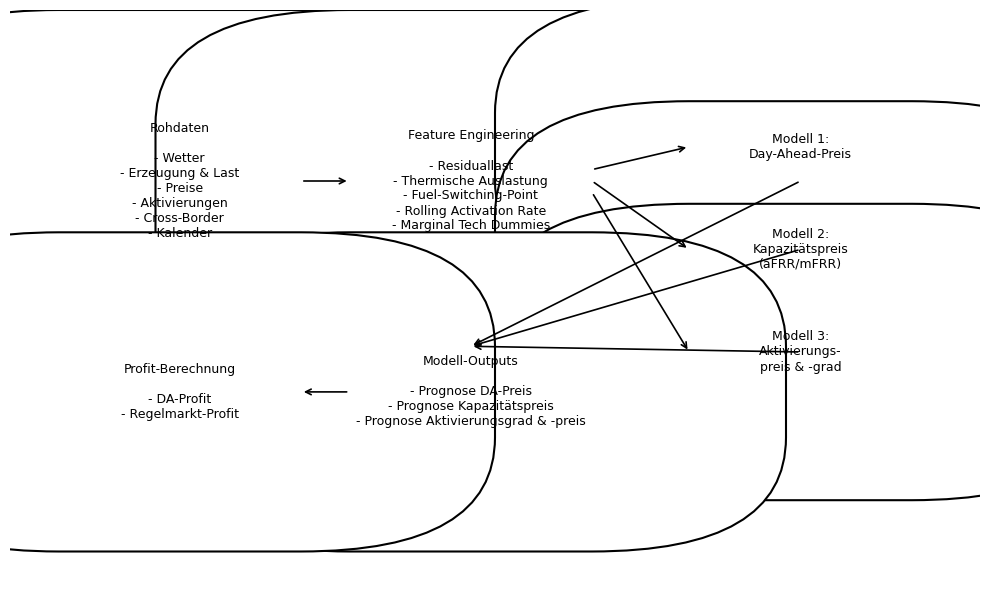

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Figure anlegen
fig, ax = plt.subplots(figsize=(10, 6))

# Helper-Funktion zum Zeichnen eines Blocks
def draw_block(x, y, w, h, text):
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.2",
        edgecolor="black",
        facecolor="white",
        linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(
        x + w/2, y + h/2,
        text,
        ha="center", va="center",
        fontsize=9
    )

# Blöcke (IEEE-Style: schlicht, klar, wenige Farben)
# Schritt 1: Rohdaten
draw_block(
    x=0.05, y=0.6, w=0.25, h=0.2,
    text="Rohdaten\n\n- Wetter\n- Erzeugung & Last\n- Preise\n- Aktivierungen\n- Cross-Border\n- Kalender"
)

# Schritt 2: Feature Engineering
draw_block(
    x=0.35, y=0.6, w=0.25, h=0.2,
    text="Feature Engineering\n\n- Residuallast\n- Thermische Auslastung\n- Fuel-Switching-Point\n- Rolling Activation Rate\n- Marginal Tech Dummies"
)

# Schritt 3: Modelle (3 Blöcke untereinander)
draw_block(
    x=0.7, y=0.7, w=0.23, h=0.12,
    text="Modell 1:\nDay-Ahead-Preis"
)
draw_block(
    x=0.7, y=0.52, w=0.23, h=0.12,
    text="Modell 2:\nKapazitätspreis\n(aFRR/mFRR)"
)
draw_block(
    x=0.7, y=0.34, w=0.23, h=0.12,
    text="Modell 3:\nAktivierungs-\npreis & -grad"
)

# Schritt 4: Modell-Outputs (zentral unten)
draw_block(
    x=0.35, y=0.25, w=0.25, h=0.16,
    text="Modell-Outputs\n\n- Prognose DA-Preis\n- Prognose Kapazitätspreis\n- Prognose Aktivierungsgrad & -preis"
)

# Schritt 5: Profit-Berechnung (links unten)
draw_block(
    x=0.05, y=0.25, w=0.25, h=0.16,
    text="Profit-Berechnung\n\n- DA-Profit\n- Regelmarkt-Profit"
)

# Pfeile zeichnen (schlicht, IEEE-Style)
def arrow(x1, y1, x2, y2):
    ax.annotate(
        "",
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle="->", linewidth=1.2, color="black")
    )

# Flow: Rohdaten -> Feature Engineering
arrow(0.30, 0.70, 0.35, 0.70)

# Flow: Feature Eng. -> alle drei Modelle
arrow(0.60, 0.72, 0.70, 0.76)   # zu Modell 1
arrow(0.60, 0.70, 0.70, 0.58)   # zu Modell 2
arrow(0.60, 0.68, 0.70, 0.40)   # zu Modell 3

# Flow: Modelle -> Modell-Outputs
arrow(0.815, 0.70, 0.475, 0.41)  # von Modell 1
arrow(0.815, 0.58, 0.475, 0.41)  # von Modell 2
arrow(0.815, 0.40, 0.475, 0.41)  # von Modell 3

# Flow: Outputs -> Profit-Berechnung
arrow(0.35, 0.33, 0.30, 0.33)

# Achsen ausschalten
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

plt.tight_layout()
plt.show()